# Treasuries


> **Setting — September 30, 2020.** This snapshot is the peak of the COVID-era surge in Treasury **bill** issuance: bills reached ~25% of marketable debt as Treasury funded emergency stimulus with short-term paper, and new coupon issues carried near-zero rates. As you build each view below, **compare it to the current (2026) picture in the Treasury Debt discussion** — how do the bill share, coupon levels, and total debt outstanding differ, and why?

***

# Data

Use the data file `../data/treasury_quotes_2020-09-30.xlsx`.

***

# 1. Treasury Debt Composition

### Data
Use the data in the `quotes` tab.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

treasury_data = 'treasury_quotes_2020-09-30.xlsx'

## 1.1
Plot the total amount of outstanding debt maturing at each date

* Do this for `total size`, as that is listed for T-bills.
* (You could also examine `public size`, but that will exclude T-bills.)

Tip: `.pivot_table()` may be useful.

## 1.2
Plot the amount of outstanding debt maturing at each date, segmented by bonds, notes, TIPS.

## 1.3
Report the total outstanding debt (summed over all maturity dates,) segmented by bonds, notes, TIPS.

## 1.4
Make a pie chart of this total number (reported in 1.3.) 

<Axes: xlabel='maturity date'>

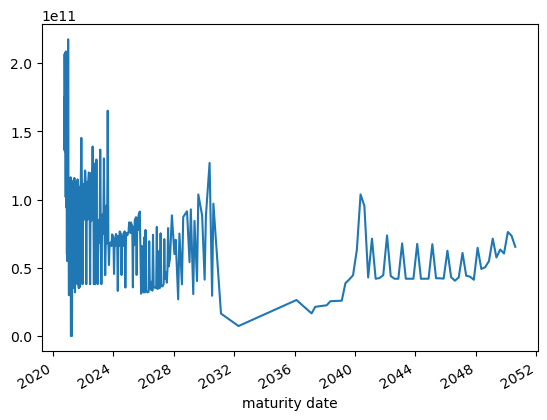

In [8]:
# 1.1 
treasury_quotes = pd.read_excel(treasury_data, sheet_name='quotes')
maturity_totals = treasury_quotes.groupby('maturity date')['total size'].sum()
maturity_totals.plot()

array([<Axes: xlabel='maturity date'>, <Axes: xlabel='maturity date'>,
       <Axes: xlabel='maturity date'>, <Axes: xlabel='maturity date'>,
       <Axes: xlabel='maturity date'>], dtype=object)

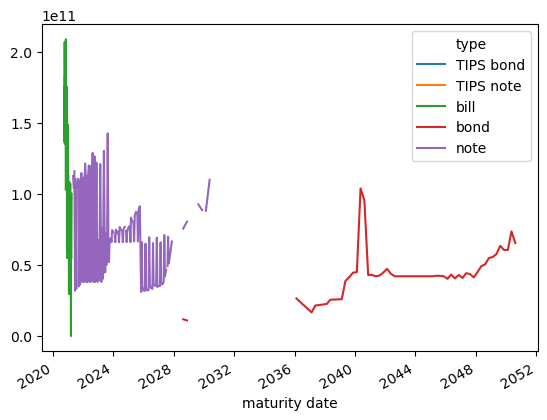

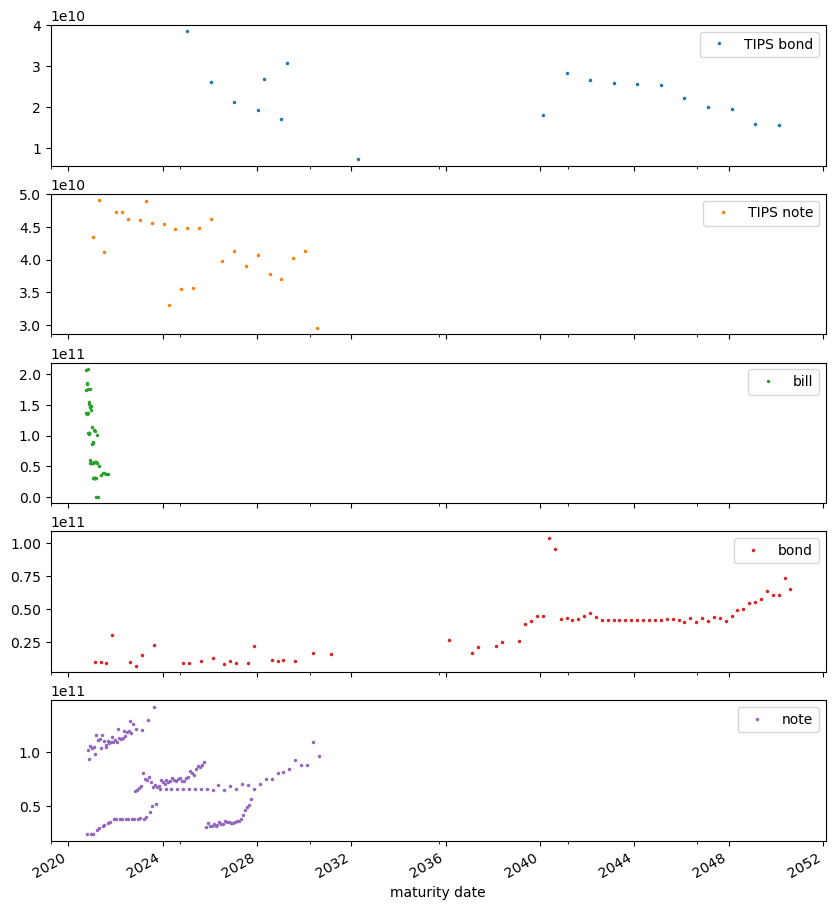

In [16]:
# 1.2 
maturity_by_type = treasury_quotes.pivot_table(
    index = 'maturity date',
    columns = 'type',
    values = 'total size',
    aggfunc = 'sum'
)
maturity_by_type.plot()
maturity_by_type.plot(subplots=True, figsize=(10, 12), style='.', markersize=3)


In [22]:
# 1.3
total_by_type = maturity_by_type.sum()
print(total_by_type)

type
TIPS bond    4.305310e+11
TIPS note    1.092660e+12
bill         5.028905e+12
bond         2.673465e+12
note         1.066373e+13
dtype: float64


<Axes: >

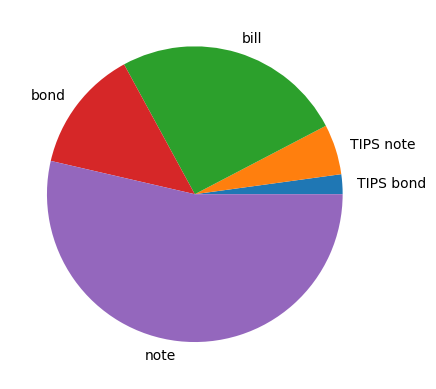

In [24]:
# 1.4
total_by_type.plot(kind='pie')

## 1.5

Calculate the time-to-maturity (relative to the quoted date) for each issue.

Report the summary statistics of these time-to-maturities. 

Consider using `.describe()`

In [28]:
# 1.5 
treasury_quotes['ttm'].describe()

count    415.000000
mean       6.141092
std        7.987937
min        0.002738
25%        0.895277
50%        2.915811
75%        6.599589
max       29.872690
Name: ttm, dtype: float64